# A Predictive Model for US Airline Flight Delays - Decision Forests with and without Balanced Sample Weights

### <span style="color:chocolate"> Project Description </span>

Flight delay prediction is an important research field, as flight delays are the primary concern of aviation
stakeholders. Our project aims to identify the predictors of flight delays before they happen, improve
travelers experience, and help airlines shift from reactive damage control to proactive delay management.

---
### <span style="color:chocolate">Import libraries</span>

In [1]:
import numpy as np
import pandas as pd
#from keras.src.backend.config import max_steps_per_epoch
#from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
#from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
#from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import OrdinalEncoder

from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import plotly.express as px

---
### <span style="color:chocolate">Data Ingestion</span>

Reading the cleaned and combined data from 2022 to 2026 to the data frame downloaded from the following data sources:
- Flight data: Bureau of transportation stats https://www.transtats.bts.gov/ontime/
- Weather data (New with 2026 data): https://www.ncei.noaa.gov/access/search/data-search/global-historical-climatology-network-hourly
- Aircraft data: https://www.faa.gov/licenses_certificates/aircraft_certification/aircraft_registry/releasable_aircraft_download?utm_source=chatgpt.com

In [2]:
# Read in the data.
flight_df = pd.read_parquet('Data/sfo_delay_features_2h.parquet')

In [3]:
# Sort the row by the values in 'date' column
flight_df = flight_df.sort_values('flight_date').reset_index(drop=True)

In [4]:
# Display the first five rows of data.
flight_df.head()

,flight_id,flight_date,scheduled_dep_utc,prediction_cutoff_utc,reporting_airline,dest,prediction_horizon_hours,dep_delay_minutes,cancelled,target_cancelled,...,aircraft_manufacturer,aircraft_model,number_of_engines,number_of_seats,aircraft_weight_class,aircraft_cruise_speed,engine_thrust,faa_record_type,aircraft_age_years,faa_match_flag
0,20220101_AA_2614.0_SFO_ORD_515,2022-01-01,2022-01-01 13:15:00+00:00,2022-01-01 11:15:00+00:00,AA,ORD,2,NaN,1,1,...,BOEING,737-823,2,162,CLASS 3,0,24200,MASTER,8,1
1,20220101_F9_2064.0_SFO_LAS_1532,2022-01-01,2022-01-01 23:32:00+00:00,2022-01-01 21:32:00+00:00,F9,LAS,2,64.0,0,0,...,AIRBUS,A320-251N,2,190,CLASS 3,0,27120,MASTER,4,1
2,20220101_DL_442.0_SFO_JFK_1605,2022-01-01,2022-01-02 00:05:00+00:00,2022-01-01 22:05:00+00:00,DL,JFK,2,23.0,0,0,...,BOEING,767-332,2,330,CLASS 3,0,60000,MASTER,25,1
3,20220101_UA_324.0_SFO_DEN_1605,2022-01-01,2022-01-02 00:05:00+00:00,2022-01-01 22:05:00+00:00,UA,DEN,2,0.0,0,0,...,BOEING,737-824,2,149,CLASS 3,0,0,MASTER,23,1
4,20220101_UA_447.0_SFO_SEA_1605,2022-01-01,2022-01-02 00:05:00+00:00,2022-01-01 22:05:00+00:00,UA,SEA,2,16.0,0,0,...,BOEING,737-824,2,149,CLASS 3,0,0,MASTER,22,1


In [5]:
# Look at the unique in 'target_delay_bin_label' column.
flight_df['target_delay_bin_label'].unique()

<StringArray>
[              <NA>,  '60_to_under_120',   '15_to_under_60',
         'under_15', '120_to_under_240',         '240_plus']
Length: 6, dtype: string

In [6]:
# Look at the unique in 'target_delay_bin' column.
flight_df['target_delay_bin'].unique()

<IntegerArray>
[<NA>, 2, 1, 0, 3, 4]
Length: 6, dtype: Int8

In [7]:
# Display the shape
flight_df.shape

(454748, 183)

In [8]:
# Check the types of each column
flight_df.dtypes

flight_id                             object
flight_date                   datetime64[us]
scheduled_dep_utc        datetime64[ns, UTC]
prediction_cutoff_utc    datetime64[ns, UTC]
reporting_airline             string[python]
                                ...         
aircraft_cruise_speed                  Int64
engine_thrust                          Int64
faa_record_type                       object
aircraft_age_years                     Int64
faa_match_flag                          int8
Length: 183, dtype: object

In [9]:
# Check if there is any missing values.
flight_df.isna().values.any()

np.True_

In [10]:
# Show columns with missing value and the counts
flight_df.isnull().sum()

flight_id                    0
flight_date                  0
scheduled_dep_utc            0
prediction_cutoff_utc        0
reporting_airline            0
                         ...  
aircraft_cruise_speed     5570
engine_thrust            14375
faa_record_type           5570
aircraft_age_years       15209
faa_match_flag               0
Length: 183, dtype: int64

---
#### <span style="color:chocolate">Data Preprocessing</span>



In [11]:
# Group the numeric features together.
features_numeric = [
    'prediction_horizon_hours', 'dep_delay_minutes', 'eda_only_carrier_delay_minutes', 'eda_only_weather_delay_minutes', 'eda_only_nas_delay_minutes', 'eda_only_security_delay_minutes', 'eda_only_late_aircraft_delay_minutes', 'scheduled_dep_hour', 'scheduled_arr_hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'days_until_holiday', 'days_since_holiday', 'scheduled_sfo_departures_same_hour', 'scheduled_carrier_departures_same_hour', 'distance_miles', 'scheduled_elapsed_minutes', 'hist_carrier_90d_total_count', 'hist_carrier_90d_operated_count', 'hist_carrier_90d_cancel_rate', 'hist_carrier_90d_delay_ge_15_rate', 'hist_carrier_90d_delay_ge_60_rate', 'hist_carrier_90d_delay_ge_120_rate', 'hist_carrier_90d_delay_ge_240_rate', 'hist_destination_90d_total_count', 'hist_destination_90d_operated_count', 'hist_destination_90d_cancel_rate', 'hist_destination_90d_delay_ge_15_rate', 'hist_destination_90d_delay_ge_60_rate', 'hist_destination_90d_delay_ge_120_rate', 'hist_destination_90d_delay_ge_240_rate', 'hist_carrier_destination_90d_total_count', 'hist_carrier_destination_90d_operated_count', 'hist_carrier_destination_90d_cancel_rate', 'hist_carrier_destination_90d_delay_ge_15_rate', 'hist_carrier_destination_90d_delay_ge_60_rate', 'hist_carrier_destination_90d_delay_ge_120_rate', 'hist_carrier_destination_90d_delay_ge_240_rate', 'hist_carrier_365d_total_count', 'hist_carrier_365d_operated_count', 'hist_carrier_365d_cancel_rate', 'hist_carrier_365d_delay_ge_15_rate', 'hist_carrier_365d_delay_ge_60_rate', 'hist_carrier_365d_delay_ge_120_rate', 'hist_carrier_365d_delay_ge_240_rate', 'hist_destination_365d_total_count', 'hist_destination_365d_operated_count', 'hist_destination_365d_cancel_rate', 'hist_destination_365d_delay_ge_15_rate', 'hist_destination_365d_delay_ge_60_rate', 'hist_destination_365d_delay_ge_120_rate', 'hist_destination_365d_delay_ge_240_rate', 'hist_carrier_destination_365d_total_count', 'hist_carrier_destination_365d_operated_count', 'hist_carrier_destination_365d_cancel_rate', 'hist_carrier_destination_365d_delay_ge_15_rate', 'hist_carrier_destination_365d_delay_ge_60_rate', 'hist_carrier_destination_365d_delay_ge_120_rate', 'hist_carrier_destination_365d_delay_ge_240_rate', 'hist_cause_carrier_365d_report_count', 'hist_cause_carrier_365d_carrier_positive_rate', 'hist_cause_carrier_365d_nas_positive_rate', 'hist_cause_carrier_365d_late_aircraft_positive_rate', 'hist_cause_carrier_365d_weather_positive_rate', 'hist_cause_destination_365d_report_count', 'hist_cause_destination_365d_carrier_positive_rate', 'hist_cause_destination_365d_nas_positive_rate', 'hist_cause_destination_365d_late_aircraft_positive_rate', 'hist_cause_destination_365d_weather_positive_rate', 'hist_cause_carrier_destination_365d_report_count', 'hist_cause_carrier_destination_365d_carrier_positive_rate', 'hist_cause_carrier_destination_365d_nas_positive_rate', 'hist_cause_carrier_destination_365d_late_aircraft_positive_rate', 'hist_cause_carrier_destination_365d_weather_positive_rate', 'tail_sequence_today', 'has_previous_tail_flight', 'previous_flight_matches_origin', 'previous_arrived_by_cutoff', 'previous_departed_by_cutoff', 'previous_arrival_delay_known', 'previous_departure_delay_known', 'scheduled_turnaround_minutes', 'minutes_until_previous_scheduled_arrival', 'minutes_since_previous_actual_arrival', 'sfo_departures_observed_1h', 'sfo_departures_delay_mean_1h', 'sfo_departures_delay_ge_15_rate_1h', 'sfo_departures_observed_3h', 'sfo_departures_delay_mean_3h', 'sfo_departures_delay_ge_15_rate_3h', 'sfo_departures_observed_6h', 'sfo_departures_delay_mean_6h', 'sfo_departures_delay_ge_15_rate_6h', 'sfo_arrivals_observed_1h', 'sfo_arrivals_delay_mean_1h', 'sfo_arrivals_delay_ge_15_rate_1h', 'sfo_arrivals_observed_3h', 'sfo_arrivals_delay_mean_3h', 'sfo_arrivals_delay_ge_15_rate_3h', 'sfo_arrivals_observed_6h', 'sfo_arrivals_delay_mean_6h', 'sfo_arrivals_delay_ge_15_rate_6h', 'carrier_sfo_departures_observed_3h', 'carrier_sfo_departures_delay_mean_3h', 'carrier_sfo_departures_delay_ge_15_rate_3h', 'carrier_sfo_departures_observed_6h', 'carrier_sfo_departures_delay_mean_6h', 'carrier_sfo_departures_delay_ge_15_rate_6h', 'carrier_sfo_departures_observed_24h', 'carrier_sfo_departures_delay_mean_24h', 'carrier_sfo_departures_delay_ge_15_rate_24h', 'carrier_sfo_arrivals_observed_3h', 'carrier_sfo_arrivals_delay_mean_3h', 'carrier_sfo_arrivals_delay_ge_15_rate_3h', 'carrier_sfo_arrivals_observed_6h', 'carrier_sfo_arrivals_delay_mean_6h', 'carrier_sfo_arrivals_delay_ge_15_rate_6h', 'carrier_sfo_arrivals_observed_24h', 'carrier_sfo_arrivals_delay_mean_24h', 'carrier_sfo_arrivals_delay_ge_15_rate_24h', 'carrier_destination_departures_observed_6h', 'carrier_destination_departures_delay_mean_6h', 'carrier_destination_departures_delay_ge_15_rate_6h', 'carrier_destination_departures_observed_24h', 'carrier_destination_departures_delay_mean_24h', 'carrier_destination_departures_delay_ge_15_rate_24h', 'origin_temperature_c', 'origin_dew_point_temperature_c', 'origin_relative_humidity_pct', 'origin_visibility_km', 'origin_wind_speed_mps', 'origin_wind_gust_mps', 'origin_wind_direction_degrees', 'origin_sea_level_pressure_hpa', 'origin_station_level_pressure_hpa', 'origin_ceiling_height_m', 'origin_altimeter_hpa', 'origin_precipitation_mm', 'origin_visibility_min_prior_3h', 'origin_ceiling_min_prior_3h', 'origin_wind_speed_max_prior_3h', 'origin_wind_gust_max_prior_3h', 'origin_pressure_range_prior_3h', 'origin_temperature_dewpoint_spread_c', 'origin_wind_direction_sin', 'origin_wind_direction_cos', 'origin_wind_gust_excess_mps', 'origin_freezing_precipitation_proxy', 'origin_weather_age_minutes', 'number_of_engines', 'number_of_seats', 'aircraft_weight_class', 'aircraft_cruise_speed', 'engine_thrust', 'aircraft_age_years'
]

In [12]:
# Group the categorical features together.
features_categorical = ['reporting_airline', 'dest', 'cancelled', 'target_cancelled', 'day_of_week', 'month', 'is_weekend', 'origin_flight_category_code', 'origin_is_near_freezing', 'origin_is_low_visibility', 'origin_is_low_ceiling', 'origin_is_gusty', 'aircraft_year_manufactured', 'aircraft_type_code', 'engine_type_code', 'aircraft_manufacturer', 'aircraft_model', 'faa_record_type', 'faa_match_flag']

In [13]:
# Group the date features together.
features_date = ['flight_date', 'scheduled_dep_utc', 'prediction_cutoff_utc']

In [14]:
# Convert the categorical data into category data type.
for col in features_categorical:
    flight_df[col] = flight_df[col].astype('category')

In [15]:
# Combined the numerical and categorical features together.
all_features = features_numeric + features_categorical

In [16]:
# Calculate the number of samples based on the split percentage then save the indexes number.
total_rows = len(flight_df)
train_end_idx = int(total_rows * 0.60)
val_end_idx = train_end_idx + int(total_rows * 0.20)

In [17]:
# Split the data
df_train = flight_df.iloc[:train_end_idx]
df_val   = flight_df.iloc[train_end_idx:val_end_idx]
df_test  = flight_df.iloc[val_end_idx:]

In [18]:
# Display the first few row of the training data.
df_train.head()

,flight_id,flight_date,scheduled_dep_utc,prediction_cutoff_utc,reporting_airline,dest,prediction_horizon_hours,dep_delay_minutes,cancelled,target_cancelled,...,aircraft_manufacturer,aircraft_model,number_of_engines,number_of_seats,aircraft_weight_class,aircraft_cruise_speed,engine_thrust,faa_record_type,aircraft_age_years,faa_match_flag
0,20220101_AA_2614.0_SFO_ORD_515,2022-01-01,2022-01-01 13:15:00+00:00,2022-01-01 11:15:00+00:00,AA,ORD,2,NaN,1,1,...,BOEING,737-823,2,162,CLASS 3,0,24200,MASTER,8,1
1,20220101_F9_2064.0_SFO_LAS_1532,2022-01-01,2022-01-01 23:32:00+00:00,2022-01-01 21:32:00+00:00,F9,LAS,2,64.0,0,0,...,AIRBUS,A320-251N,2,190,CLASS 3,0,27120,MASTER,4,1
2,20220101_DL_442.0_SFO_JFK_1605,2022-01-01,2022-01-02 00:05:00+00:00,2022-01-01 22:05:00+00:00,DL,JFK,2,23.0,0,0,...,BOEING,767-332,2,330,CLASS 3,0,60000,MASTER,25,1
3,20220101_UA_324.0_SFO_DEN_1605,2022-01-01,2022-01-02 00:05:00+00:00,2022-01-01 22:05:00+00:00,UA,DEN,2,0.0,0,0,...,BOEING,737-824,2,149,CLASS 3,0,0,MASTER,23,1
4,20220101_UA_447.0_SFO_SEA_1605,2022-01-01,2022-01-02 00:05:00+00:00,2022-01-01 22:05:00+00:00,UA,SEA,2,16.0,0,0,...,BOEING,737-824,2,149,CLASS 3,0,0,MASTER,22,1


In [19]:
# Synchronize final feature collection arrays
X_train = df_train[all_features].copy()
y_train = df_train['target_delay_bin'].copy()

X_val   = df_val[all_features].copy()
y_val   = df_val['target_delay_bin'].copy()

X_test  = df_test[all_features].copy()
y_test  = df_test['target_delay_bin'].copy()

In [20]:
# Replace the missing 'nan' value with the word 'missing' in all categorical data.
cols_with_nan = list(X_train.select_dtypes(include=['object', 'string', 'category']).columns)

X_train[cols_with_nan] = X_train[cols_with_nan].astype(str).replace('nan', 'Missing').astype('category')
X_val[cols_with_nan] = X_val[cols_with_nan].astype(str).replace('nan', 'Missing').astype('category')
X_test[cols_with_nan] = X_test[cols_with_nan].astype(str).replace('nan', 'Missing').astype('category')

features_categorical = cols_with_nan

In [21]:
# Replace all <NA> to '5' in the expected output data.
y_train = y_train.fillna(5)
y_val = y_val.fillna(5)
y_test = y_test.fillna(5)

In [22]:
# Display the first five rows of X_train.
print(X_train)

        prediction_horizon_hours  dep_delay_minutes  \
0                              2                NaN   
1                              2               64.0   
2                              2               23.0   
3                              2                0.0   
4                              2               16.0   
...                          ...                ...   
272843                         2                5.0   
272844                         2               -8.0   
272845                         2               -6.0   
272846                         2               -7.0   
272847                         2               -3.0   

        eda_only_carrier_delay_minutes  eda_only_weather_delay_minutes  \
0                                  NaN                             NaN   
1                                  0.0                             0.0   
2                                 15.0                             0.0   
3                                  NaN     

---
### <span style="color:chocolate">Exploratory data analysis (EDA)</span>

In [23]:
# Convert X_train to pandas dataframe.
df_train = pd.DataFrame(X_train)
# Add the expected output as 'target_delay_bin' column in the X_train dataframe.
df_train['target_delay_bin'] = y_train

In [24]:
# Display the top few columns in df_train dataframe.
df_train.head()

,prediction_horizon_hours,dep_delay_minutes,eda_only_carrier_delay_minutes,eda_only_weather_delay_minutes,eda_only_nas_delay_minutes,eda_only_security_delay_minutes,eda_only_late_aircraft_delay_minutes,scheduled_dep_hour,scheduled_arr_hour,hour_sin,...,origin_is_low_ceiling,origin_is_gusty,aircraft_year_manufactured,aircraft_type_code,engine_type_code,aircraft_manufacturer,aircraft_model,faa_record_type,faa_match_flag,target_delay_bin
0,2,NaN,NaN,NaN,NaN,NaN,NaN,5,11,0.965926,...,0.0,0.0,2014,5,5,BOEING,737-823,MASTER,1,5
1,2,64.0,0.0,0.0,0.0,0.0,45.0,15,17,-0.707107,...,0.0,0.0,2018,5,5,AIRBUS,A320-251N,MASTER,1,2
2,2,23.0,15.0,0.0,0.0,0.0,0.0,16,0,-0.866025,...,0.0,0.0,1997,5,5,BOEING,767-332,MASTER,1,1
3,2,0.0,NaN,NaN,NaN,NaN,NaN,16,19,-0.866025,...,0.0,0.0,1999,5,5,BOEING,737-824,MASTER,1,0
4,2,16.0,NaN,NaN,NaN,NaN,NaN,16,18,-0.866025,...,0.0,0.0,2000,5,5,BOEING,737-824,MASTER,1,1


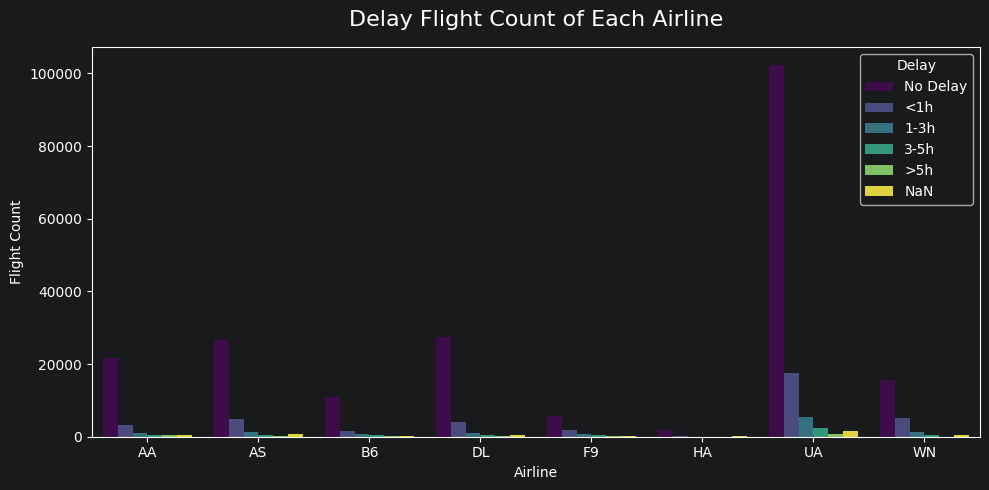

In [25]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the delay airline count histogram
ax = sns.countplot(data=df_train, x='reporting_airline', hue='target_delay_bin', palette='viridis', color='gold')
plt.title('Delay Flight Count of Each Airline', fontsize=16, pad=15)
plt.xlabel('Airline', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Define the labels for delay category.
delay_labels = ['No Delay', '<1h', '1-3h', '3-5h', '>5h', 'NaN']
# Get the current legend handles and replace the labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=delay_labels, title='Delay')

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

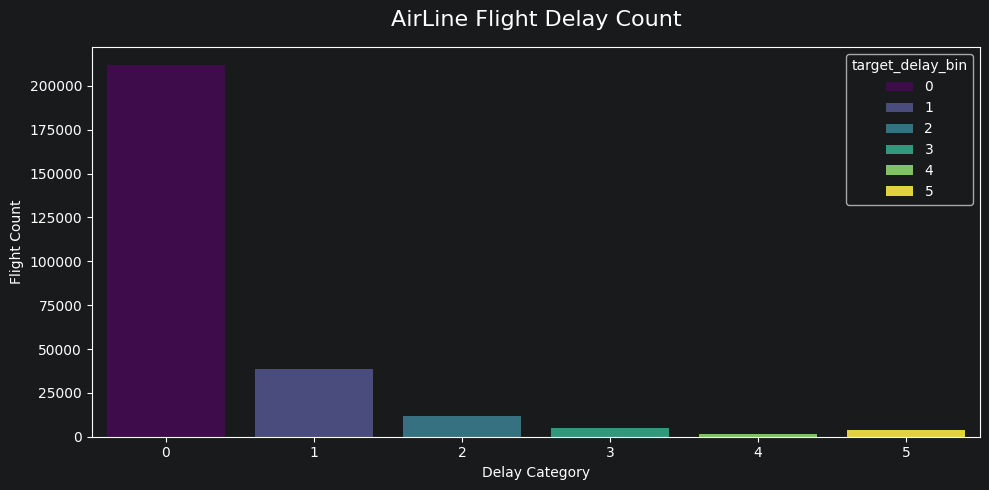

In [26]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the flight count histogram
sns.countplot(data=df_train, x='target_delay_bin', hue='target_delay_bin', palette='viridis', color='gold')
plt.title('AirLine Flight Delay Count', fontsize=16, pad=15)
plt.xlabel('Delay Category', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

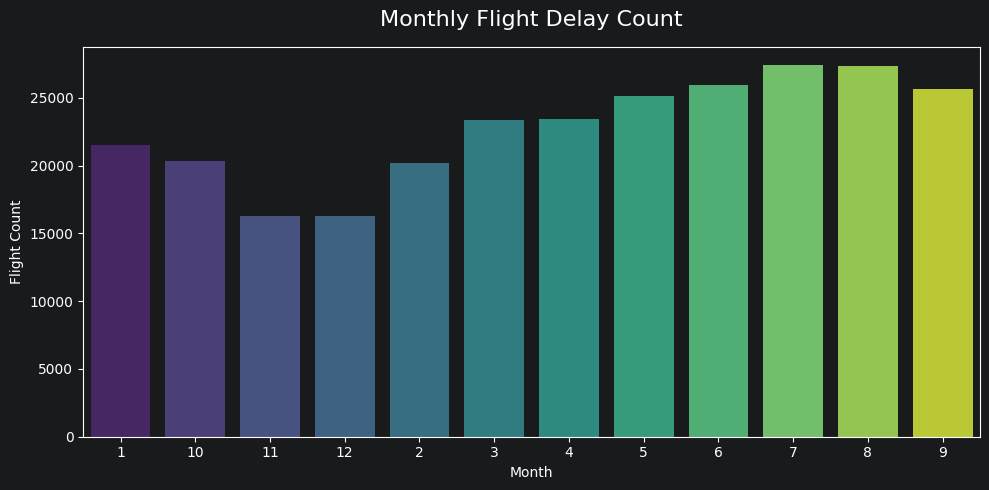

In [27]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the monthly delay flight count histogram
sns.countplot(data=df_train, x='month', hue='month', palette='viridis', color='gold')
plt.title('Monthly Flight Delay Count', fontsize=16, pad=15)
plt.xlabel('Month', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

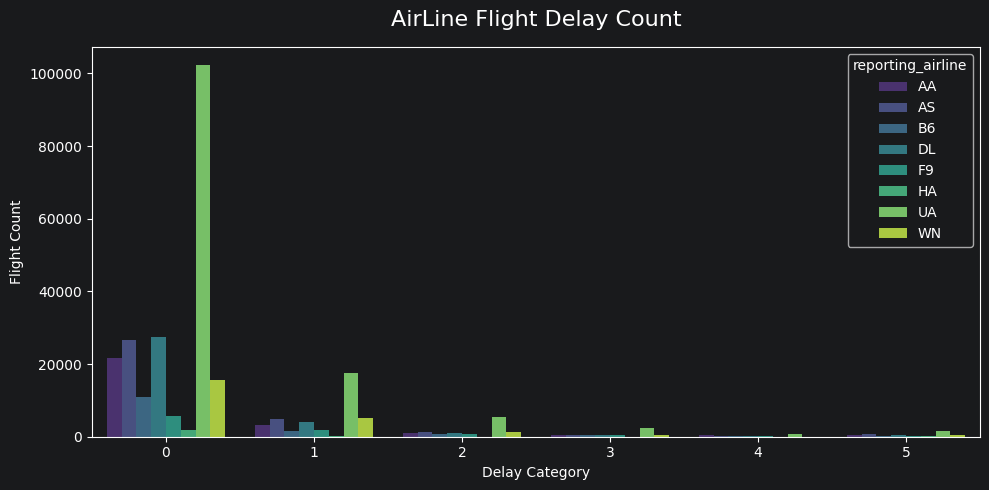

In [28]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the delay airline flight count histogram
sns.countplot(data=df_train, x='target_delay_bin', hue='reporting_airline', palette='viridis')
plt.title('AirLine Flight Delay Count', fontsize=16, pad=15)
plt.xlabel('Delay Category', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

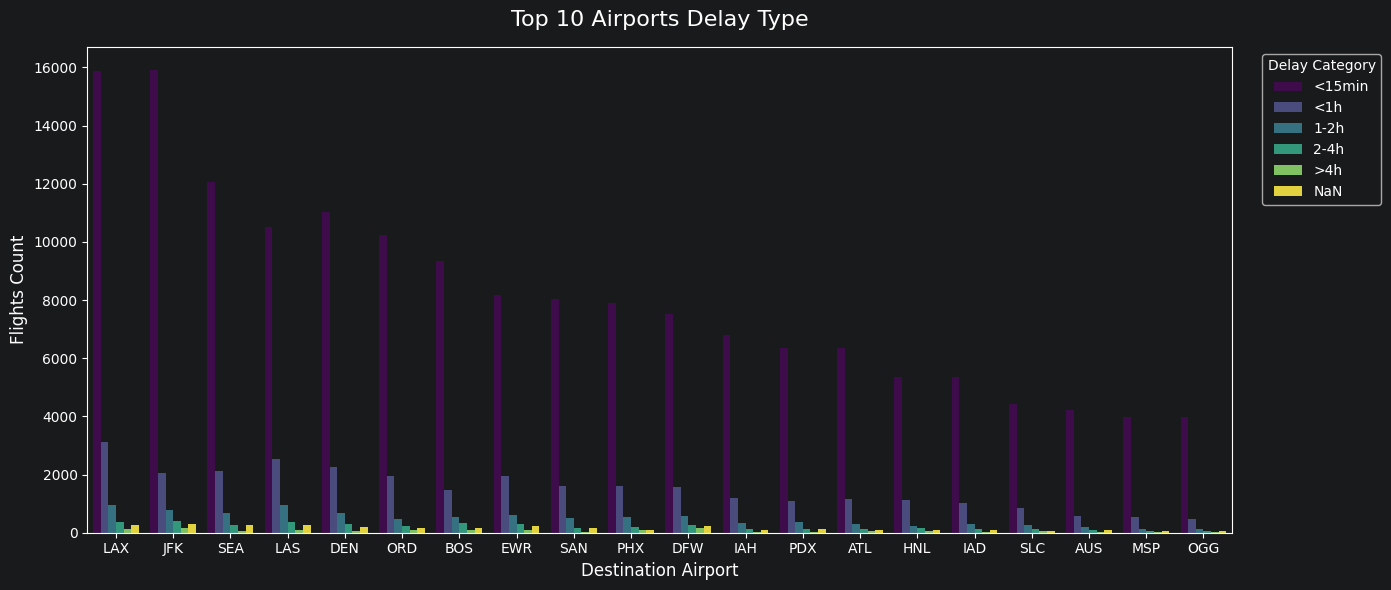

In [29]:
# Only select the top 20 airports with most delay.
top_20_airports = df_train['dest'].value_counts().head(20).index
df_top_20_delayed = df_train[df_train['dest'].isin(top_20_airports)]

# Set up the matplotlib figure
plt.figure(figsize=(14, 6))

# Plot the airport delay count histogram
ax = sns.countplot(
    data=df_top_20_delayed,
    x='dest',
    hue='target_delay_bin',
    order=top_20_airports,
    palette='viridis'
)

# Define the labels for delay category.
delay_labels = ['<15min', '<1h', '1-2h', '2-4h', '>4h', 'NaN']
# Get the current legend handles and replace the labels
handles, _ = ax.get_legend_handles_labels()

# Plot the flight count histogram
plt.title('Top 10 Airports Delay Type', fontsize=16, pad=15)
plt.xlabel('Destination Airport', fontsize=12)
plt.ylabel('Flights Count', fontsize=12)
plt.legend(title='Delay Category', bbox_to_anchor=(1.02, 1), loc='upper left', handles=handles, labels=delay_labels)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

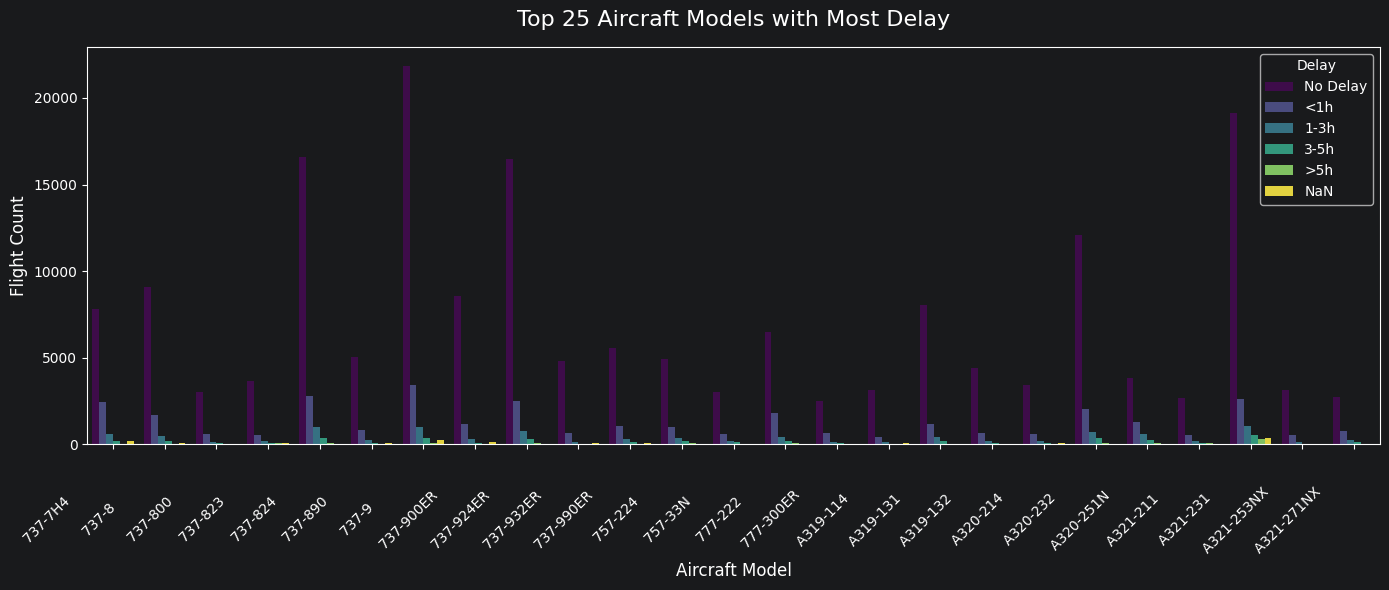

In [30]:
# Only select the top 25 aircraft models with most delay.
top_25_years = df_train['aircraft_model'].value_counts().iloc[:25].index
df_filtered = df_train[df_train['aircraft_model'].isin(top_25_years)].copy()
# Drop the empty aircraft models such that they won't display on the x-axis.
df_filtered['aircraft_model'] = df_filtered['aircraft_model'].cat.remove_unused_categories()

# Plot the top 25 aircraft models with most delay histogram
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df_filtered,
    x='aircraft_model',
    hue='target_delay_bin',
    palette='viridis'
)

# Define the labels for delay category.
delay_labels = ['No Delay', '<1h', '1-3h', '3-5h', '>5h', 'NaN']
# Get the current legend handles and replace the labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=delay_labels, title='Delay')

# Rotate labels 45 degrees to fit all 25 aircraft models in x-axis
plt.xticks(rotation=45, ha='right')
plt.title('Top 25 Aircraft Models with Most Delay', fontsize=16, pad=15)
plt.xlabel('Aircraft Model', fontsize=12)
plt.ylabel('Flight Count', fontsize=12)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

In [31]:
# Select all the numerical data column for analysis
numeric_cols = [
    'prediction_horizon_hours', 'dep_delay_minutes', 'eda_only_carrier_delay_minutes', 'eda_only_weather_delay_minutes', 'eda_only_nas_delay_minutes', 'eda_only_security_delay_minutes', 'eda_only_late_aircraft_delay_minutes', 'scheduled_dep_hour', 'scheduled_arr_hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'days_until_holiday', 'days_since_holiday', 'scheduled_sfo_departures_same_hour', 'scheduled_carrier_departures_same_hour', 'distance_miles', 'scheduled_elapsed_minutes', 'hist_carrier_90d_total_count', 'hist_carrier_90d_operated_count', 'hist_carrier_90d_cancel_rate', 'hist_carrier_90d_delay_ge_15_rate', 'hist_carrier_90d_delay_ge_60_rate', 'hist_carrier_90d_delay_ge_120_rate', 'hist_carrier_90d_delay_ge_240_rate', 'hist_destination_90d_total_count', 'hist_destination_90d_operated_count', 'hist_destination_90d_cancel_rate', 'hist_destination_90d_delay_ge_15_rate', 'hist_destination_90d_delay_ge_60_rate', 'hist_destination_90d_delay_ge_120_rate', 'hist_destination_90d_delay_ge_240_rate', 'hist_carrier_destination_90d_total_count', 'hist_carrier_destination_90d_operated_count', 'hist_carrier_destination_90d_cancel_rate', 'hist_carrier_destination_90d_delay_ge_15_rate', 'hist_carrier_destination_90d_delay_ge_60_rate', 'hist_carrier_destination_90d_delay_ge_120_rate', 'hist_carrier_destination_90d_delay_ge_240_rate', 'hist_carrier_365d_total_count', 'hist_carrier_365d_operated_count', 'hist_carrier_365d_cancel_rate', 'hist_carrier_365d_delay_ge_15_rate', 'hist_carrier_365d_delay_ge_60_rate', 'hist_carrier_365d_delay_ge_120_rate', 'hist_carrier_365d_delay_ge_240_rate', 'hist_destination_365d_total_count', 'hist_destination_365d_operated_count', 'hist_destination_365d_cancel_rate', 'hist_destination_365d_delay_ge_15_rate', 'hist_destination_365d_delay_ge_60_rate', 'hist_destination_365d_delay_ge_120_rate', 'hist_destination_365d_delay_ge_240_rate', 'hist_carrier_destination_365d_total_count', 'hist_carrier_destination_365d_operated_count', 'hist_carrier_destination_365d_cancel_rate', 'hist_carrier_destination_365d_delay_ge_15_rate', 'hist_carrier_destination_365d_delay_ge_60_rate', 'hist_carrier_destination_365d_delay_ge_120_rate', 'hist_carrier_destination_365d_delay_ge_240_rate', 'hist_cause_carrier_365d_report_count', 'hist_cause_carrier_365d_carrier_positive_rate', 'hist_cause_carrier_365d_nas_positive_rate', 'hist_cause_carrier_365d_late_aircraft_positive_rate', 'hist_cause_carrier_365d_weather_positive_rate', 'hist_cause_destination_365d_report_count', 'hist_cause_destination_365d_carrier_positive_rate', 'hist_cause_destination_365d_nas_positive_rate', 'hist_cause_destination_365d_late_aircraft_positive_rate', 'hist_cause_destination_365d_weather_positive_rate', 'hist_cause_carrier_destination_365d_report_count', 'hist_cause_carrier_destination_365d_carrier_positive_rate', 'hist_cause_carrier_destination_365d_nas_positive_rate', 'hist_cause_carrier_destination_365d_late_aircraft_positive_rate', 'hist_cause_carrier_destination_365d_weather_positive_rate', 'tail_sequence_today', 'has_previous_tail_flight', 'previous_flight_matches_origin', 'previous_arrived_by_cutoff', 'previous_departed_by_cutoff', 'previous_arrival_delay_known', 'previous_departure_delay_known', 'scheduled_turnaround_minutes', 'minutes_until_previous_scheduled_arrival', 'minutes_since_previous_actual_arrival', 'sfo_departures_observed_1h', 'sfo_departures_delay_mean_1h', 'sfo_departures_delay_ge_15_rate_1h', 'sfo_departures_observed_3h', 'sfo_departures_delay_mean_3h', 'sfo_departures_delay_ge_15_rate_3h', 'sfo_departures_observed_6h', 'sfo_departures_delay_mean_6h', 'sfo_departures_delay_ge_15_rate_6h', 'sfo_arrivals_observed_1h', 'sfo_arrivals_delay_mean_1h', 'sfo_arrivals_delay_ge_15_rate_1h', 'sfo_arrivals_observed_3h', 'sfo_arrivals_delay_mean_3h', 'sfo_arrivals_delay_ge_15_rate_3h', 'sfo_arrivals_observed_6h', 'sfo_arrivals_delay_mean_6h', 'sfo_arrivals_delay_ge_15_rate_6h', 'carrier_sfo_departures_observed_3h', 'carrier_sfo_departures_delay_mean_3h', 'carrier_sfo_departures_delay_ge_15_rate_3h', 'carrier_sfo_departures_observed_6h', 'carrier_sfo_departures_delay_mean_6h', 'carrier_sfo_departures_delay_ge_15_rate_6h', 'carrier_sfo_departures_observed_24h', 'carrier_sfo_departures_delay_mean_24h', 'carrier_sfo_departures_delay_ge_15_rate_24h', 'carrier_sfo_arrivals_observed_3h', 'carrier_sfo_arrivals_delay_mean_3h', 'carrier_sfo_arrivals_delay_ge_15_rate_3h', 'carrier_sfo_arrivals_observed_6h', 'carrier_sfo_arrivals_delay_mean_6h', 'carrier_sfo_arrivals_delay_ge_15_rate_6h', 'carrier_sfo_arrivals_observed_24h', 'carrier_sfo_arrivals_delay_mean_24h', 'carrier_sfo_arrivals_delay_ge_15_rate_24h', 'carrier_destination_departures_observed_6h', 'carrier_destination_departures_delay_mean_6h', 'carrier_destination_departures_delay_ge_15_rate_6h', 'carrier_destination_departures_observed_24h', 'carrier_destination_departures_delay_mean_24h', 'carrier_destination_departures_delay_ge_15_rate_24h', 'origin_temperature_c', 'origin_dew_point_temperature_c', 'origin_relative_humidity_pct', 'origin_visibility_km', 'origin_wind_speed_mps', 'origin_wind_gust_mps', 'origin_wind_direction_degrees', 'origin_sea_level_pressure_hpa', 'origin_station_level_pressure_hpa', 'origin_ceiling_height_m', 'origin_altimeter_hpa', 'origin_precipitation_mm', 'origin_visibility_min_prior_3h', 'origin_ceiling_min_prior_3h', 'origin_wind_speed_max_prior_3h', 'origin_wind_gust_max_prior_3h', 'origin_pressure_range_prior_3h', 'origin_temperature_dewpoint_spread_c', 'origin_wind_direction_sin', 'origin_wind_direction_cos', 'origin_wind_gust_excess_mps', 'origin_freezing_precipitation_proxy', 'origin_weather_age_minutes', 'number_of_engines', 'number_of_seats', 'aircraft_weight_class', 'aircraft_cruise_speed', 'engine_thrust', 'aircraft_age_years'
]

In [32]:
# Interactive correlation matrix
# Convert all the values in 'target_delay_bin' column to integer.
df_train['target_delay_bin'] = df_train['target_delay_bin'].astype(int)
# Calculate the linear correlation coefficients between all the numeric features.
correlation_matrix = df_train.corr(numeric_only=True)
# Plot the correlation matrix
fig = px.imshow(
    correlation_matrix,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    #color_continuous_scale='Viridis',
    color_continuous_scale='blues',
    zmin=-1, zmax=1,
    width=1000, height=1000
)

# Add the title
fig.update_layout(title="Flight Delay Numerical Features Correlation Matrix")
# Display the plots.
fig.show()

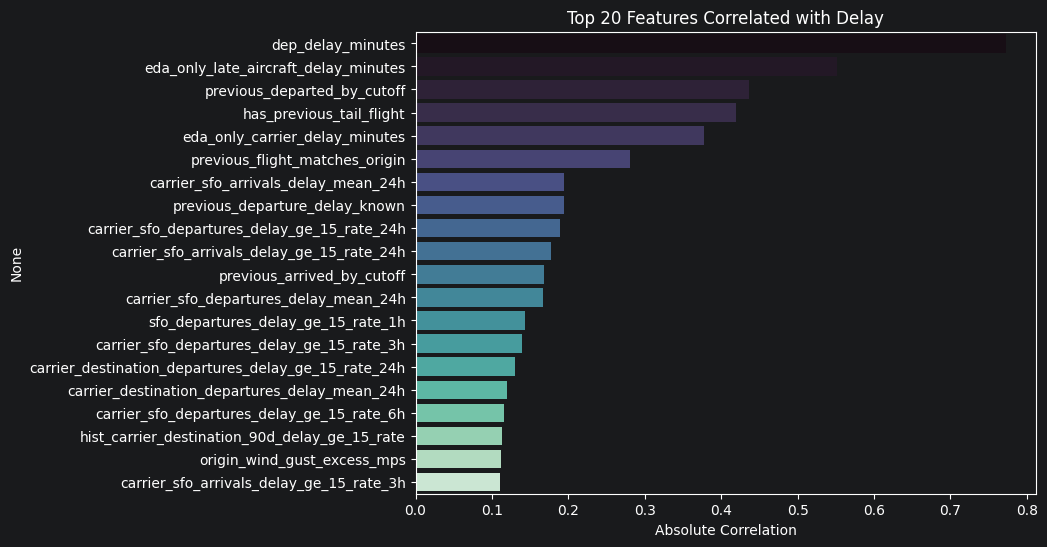

In [33]:
# Calculate absolute correlation between the numeric features and delay duration range/target_delay_bin
target_corr = (
    correlation_matrix['target_delay_bin']
    .drop('target_delay_bin')
    .abs()
    .sort_values(ascending=False)
)

# Plot top 20 features with highest correlation.
plt.figure(figsize=(8, 6))
sns.barplot(
    x=target_corr.head(20).values,
    y=target_corr.head(20).index,
    hue=target_corr.head(20).index,
    legend=False,
    palette='mako'
)
plt.title(f'Top 20 Features Correlated with Delay')
plt.xlabel('Absolute Correlation')
plt.show()

---
### <span style="color:chocolate">Improved Model</span>

In [34]:
# Select the most useful numeric features based on the EDA above
features_numeric_updated = [
    'previous_departed_by_cutoff', 'eda_only_nas_delay_minutes',
    'carrier_sfo_arrivals_delay_mean_24h', 'carrier_sfo_departures_delay_ge_15_rate_24h',
    'carrier_sfo_arrivals_delay_ge_15_rate_24h', 'carrier_sfo_departures_delay_mean_24h',
    'sfo_departures_delay_ge_15_rate_1h', 'previous_departure_delay_known', 'previous_arrived_by_cutoff',
    'carrier_sfo_departures_delay_ge_15_rate_3h', 'hist_carrier_destination_90d_delay_ge_15_rate',
    'carrier_destination_departures_delay_mean_24h', 'sfo_arrivals_delay_ge_15_rate_1h',
    'hist_carrier_destination_90d_delay_ge_120_rate', 'hist_carrier_90d_delay_ge_60_rate',
    'hist_carrier_destination_90d_delay_ge_60_rate', 'carrier_destination_departures_delay_ge_15_rate_24h'
]

# Select the most useful categorical features based on the EDA above
features_categorical_updated = [
    'reporting_airline', 'dest', 'cancelled', 'target_cancelled',
    'day_of_week', 'month', 'is_weekend', 'origin_flight_category_code',
    'origin_is_near_freezing', 'origin_is_low_visibility', 'origin_is_low_ceiling',
    'origin_is_gusty', 'aircraft_year_manufactured', 'aircraft_type_code',
    'engine_type_code', 'aircraft_manufacturer', 'aircraft_model',
    'faa_record_type', 'faa_match_flag'
]

In [35]:
# Combine the numerical and categorical features
columns_to_keep = features_numeric_updated + features_categorical_updated

# Slice the dataframes cleanly
X_train_updated = df_train[columns_to_keep]
y_train_updated = df_train['target_delay_bin']
X_val_updated = df_val[columns_to_keep]
y_val_updated = df_val['target_delay_bin']
X_test_updated = df_test[columns_to_keep]
y_test_updated = df_test['target_delay_bin']

In [36]:
# Replace the missing 'nan' value with the word 'missing' in all categorical data.
X_train_updated = X_train_updated.copy()
X_val_updated = X_val_updated.copy()
X_test_updated = X_test_updated.copy()

updated_cols_with_nan = list(X_train_updated.select_dtypes(include=['object', 'string', 'category']).columns)

X_train_updated[updated_cols_with_nan] = X_train_updated[updated_cols_with_nan].astype(str).replace('nan', 'Missing').astype('category')
X_val_updated[updated_cols_with_nan] = X_val_updated[updated_cols_with_nan].astype(str).replace('nan', 'Missing').astype('category')
X_test_updated[updated_cols_with_nan] = X_test_updated[updated_cols_with_nan].astype(str).replace('nan', 'Missing').astype('category')

features_categorical_updated = updated_cols_with_nan

In [37]:
# Replace all <NA> to '5' in the expected output data.
y_train_updated = y_train_updated.fillna(5)
y_val_updated = y_val_updated.fillna(5)
y_test_updated = y_test_updated.fillna(5)

In [38]:
# Converts text categorical data into numbers to handle unexpected data and missing values.
categorical_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    encoded_missing_value=-2
)

In [39]:
# Initialize HistGradientBoostingClassifier with native categorical support and balanced sample weights
# Set the parameters based on the API and experiment/results from the previous ran/advise from the professors.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
'''
#sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights = compute_sample_weight(y=y_train)

gb_classifier = HistGradientBoostingClassifier(
    # Auto-detects the pandas 'category' columns
    categorical_features="from_dtype",
    max_iter=600,
    learning_rate=0.01,
    max_depth=5,
    min_samples_leaf=200,
    # Stops training early if validation score stagnates
    n_iter_no_change=10,
    random_state=42
)

# Train the model
#gb_classifier.fit(X_train, y_train, sample_weight=sample_weights)
gb_classifier.fit(X_train, y_train)
'''
gb_classifier = HistGradientBoostingClassifier(
    # Auto-detects the pandas 'category' columns
    categorical_features="from_dtype",
    #class_weight="balanced",
    max_iter=1000,
    learning_rate=0.05,
    max_depth=7,
    min_samples_leaf=100,
    # Stops training early if validation score stagnates
    n_iter_no_change=20,
    random_state=42
)

# Train the model
gb_classifier.fit(X_train_updated, y_train_updated)

HistGradientBoostingClassifier(learning_rate=0.05, max_depth=7, max_iter=1000,
                               min_samples_leaf=100, n_iter_no_change=20,
                               random_state=42)

In [40]:
# Evaluate the train, validation, and test set.
train_accuracy = accuracy_score(y_train, gb_classifier.predict(X_train_updated))
val_accuracy   = accuracy_score(y_val, gb_classifier.predict(X_val_updated))
test_accuracy  = accuracy_score(y_test, gb_classifier.predict(X_test_updated))

print('Training Accuracy:', train_accuracy)
print('Validation Accuracy:', val_accuracy)
print('Test Accuracy:', test_accuracy)

Training Accuracy: 0.8847343575910397
Validation Accuracy: 0.8790311053447537
Test Accuracy: 0.8677199810887181


<Figure size 1000x800 with 0 Axes>

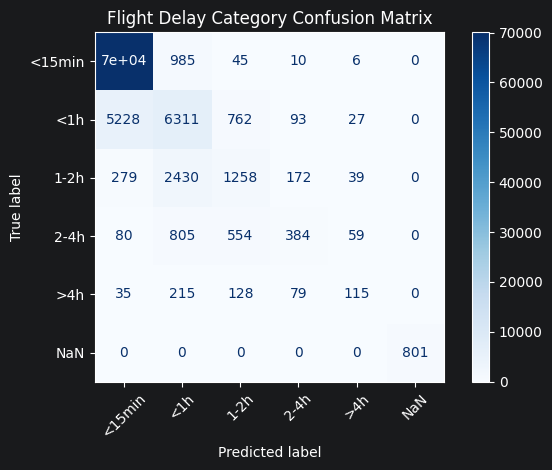

In [41]:
# Calculate the prediction on the testing data set.
y_test_pred = gb_classifier.predict(X_test_updated)

# Plot the confusion matrix.
cm = confusion_matrix(y_test_updated, y_test_pred)

# List out the class name for labeling.
delay_labels = ['<15min', '<1h', '1-2h', '2-4h', '>4h', 'NaN']

# Confusion matrix settings
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=delay_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Flight Delay Category Confusion Matrix')

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

In [42]:
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
gb_classifier_balanced = HistGradientBoostingClassifier(
    # Auto-detects the pandas 'category' columns
    categorical_features="from_dtype",
    class_weight="balanced",
    max_iter=1000,
    learning_rate=0.05,
    max_depth=7,
    min_samples_leaf=100,
    # Stops training early if validation score stagnates
    n_iter_no_change=20,
    random_state=42
)

# Train the model
gb_classifier_balanced.fit(X_train_updated, y_train_updated)

HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.05,
                               max_depth=7, max_iter=1000, min_samples_leaf=100,
                               n_iter_no_change=20, random_state=42)

In [43]:
# Evaluate the train, validation, and test set.
train_balanced_accuracy = accuracy_score(y_train, gb_classifier_balanced.predict(X_train_updated))
val_balanced_accuracy   = accuracy_score(y_val, gb_classifier_balanced.predict(X_val_updated))
test_balanced_accuracy  = accuracy_score(y_test, gb_classifier_balanced.predict(X_test_updated))

print('Training Accuracy:', train_balanced_accuracy)
print('Validation Accuracy:', val_balanced_accuracy)
print('Test Accuracy:', test_balanced_accuracy)

Training Accuracy: 0.8154137101976192
Validation Accuracy: 0.8095636015789068
Test Accuracy: 0.8023111345669647


<Figure size 1000x800 with 0 Axes>

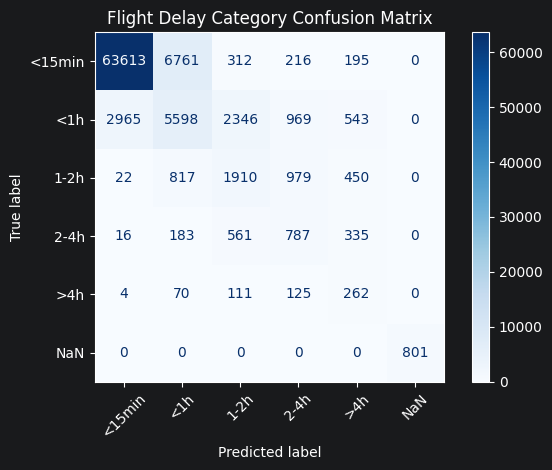

In [44]:
# Calculate the prediction on the testing data set.
y_test_balanced_pred = gb_classifier_balanced.predict(X_test_updated)

# Plot the confusion matrix.
cm = confusion_matrix(y_test_updated, y_test_balanced_pred)

# List out the class name for labeling.
delay_labels = ['<15min', '<1h', '1-2h', '2-4h', '>4h', 'NaN']

# Confusion matrix settings
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=delay_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Flight Delay Category Confusion Matrix')

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()